Problem statement

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

Import libraries

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Load files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


Read files

In [3]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')
submission = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [4]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [6]:
submission

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


Analyse dataset

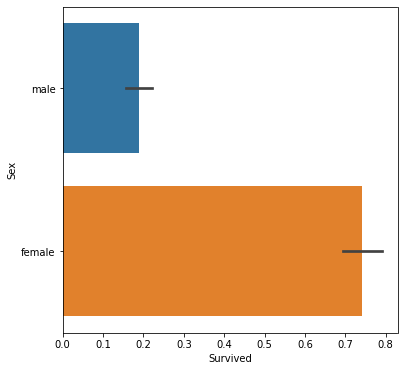

In [7]:
plt.figure(figsize=(6,6))
sns.barplot(x='Survived', y='Sex', data=train)
plt.show()

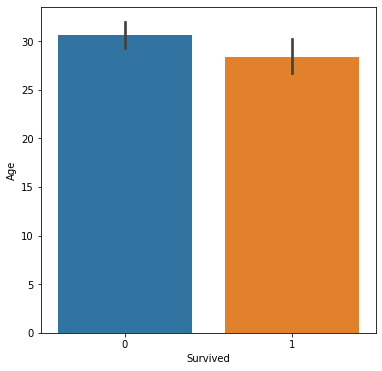

In [8]:
plt.figure(figsize=(6,6))
sns.barplot(x='Survived', y='Age', data=train)
plt.show()

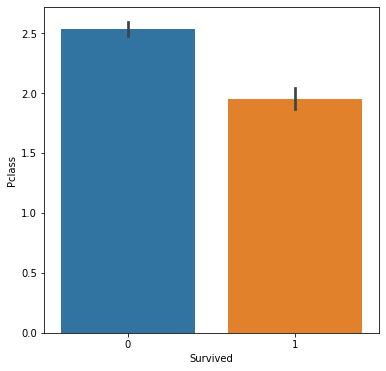

In [9]:
plt.figure(figsize=(6,6))
sns.barplot(x='Survived', y='Pclass', data=train)
plt.show()

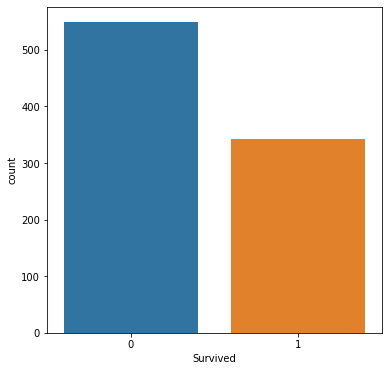

In [10]:
plt.figure(figsize=(6,6))
sns.countplot(x='Survived', data=train)
plt.show()

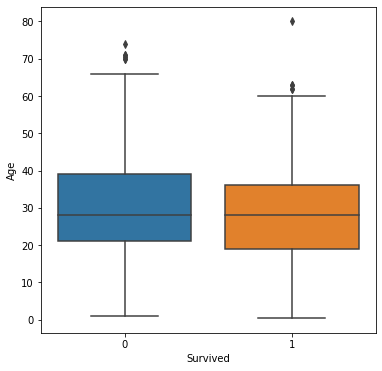

In [11]:
plt.figure(figsize=(6,6))
sns.boxplot(x='Survived', y='Age', data=train)
plt.show()

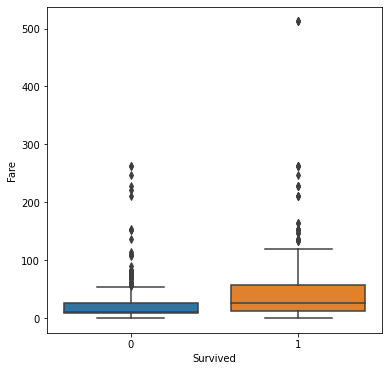

In [12]:
plt.figure(figsize=(6,6))
sns.boxplot(x='Survived', y='Fare', data=train)
plt.show()

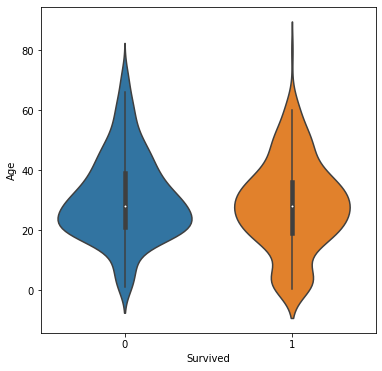

In [13]:
plt.figure(figsize=(6,6))
sns.violinplot(x='Survived', y='Age', data=train)
plt.show()

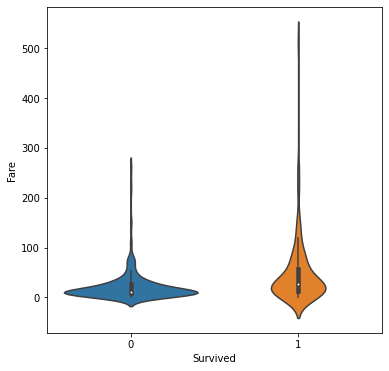

In [14]:
plt.figure(figsize=(6,6))
sns.violinplot(x='Survived', y='Fare', data=train)
plt.show()

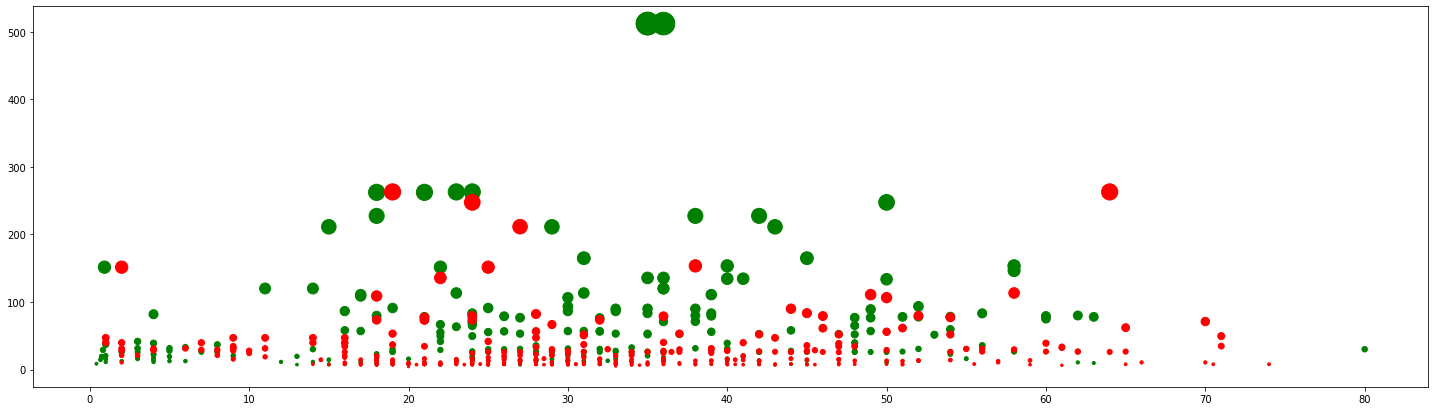

In [15]:
plt.figure(figsize=(25, 7))
ax = plt.subplot()
ax.scatter(train[train['Survived'] == 1]['Age'], train[train['Survived'] == 1]['Fare'], c='green', s=train[train['Survived'] == 1]['Fare'])
ax.scatter(train[train['Survived'] == 0]['Age'], train[train['Survived'] == 0]['Fare'], c='red', s=train[train['Survived'] == 0]['Fare']);

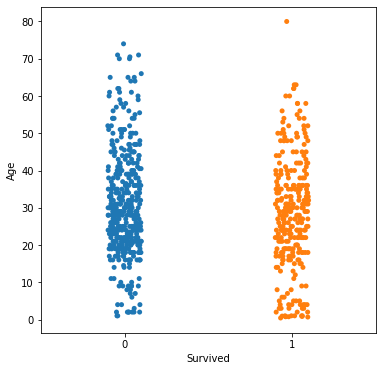

In [16]:
plt.figure(figsize=(6,6))
sns.stripplot(x='Survived', y='Age', data=train)
plt.show()

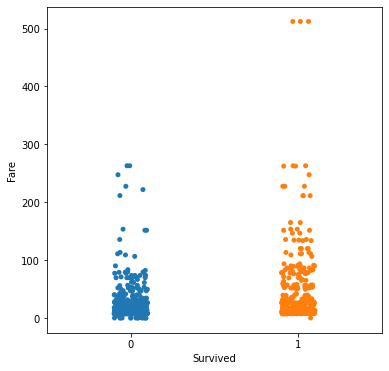

In [17]:
plt.figure(figsize=(6,6))
sns.stripplot(x='Survived', y='Fare', data=train)
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3717: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


<Figure size 432x432 with 0 Axes>

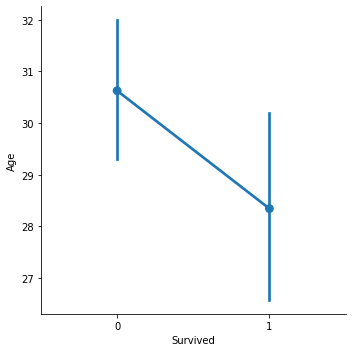

In [18]:
plt.figure(figsize=(6,6))
sns.factorplot(x='Survived', y='Age', data=train)
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/categorical.py:3717: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


<Figure size 432x432 with 0 Axes>

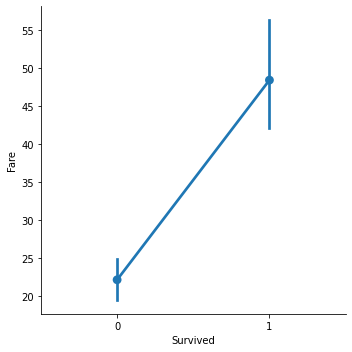

In [19]:
plt.figure(figsize=(6,6))
sns.factorplot(x='Survived', y='Fare', data=train)
plt.show()

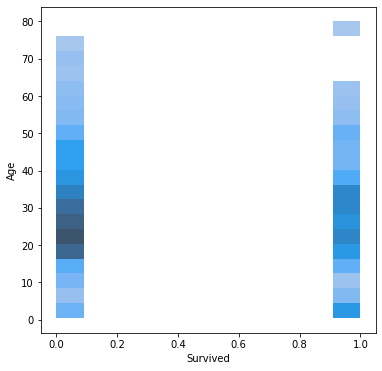

In [20]:
plt.figure(figsize=(6,6))
sns.histplot(x='Survived', y='Age', data=train)
plt.show()

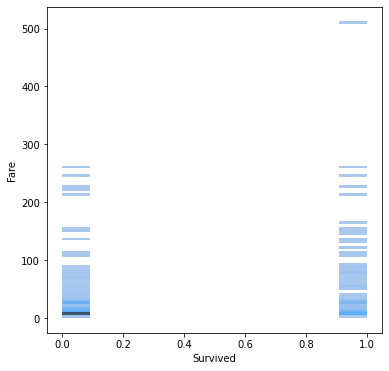

In [21]:
plt.figure(figsize=(6,6))
sns.histplot(x='Survived', y='Fare', data=train)
plt.show()

<Figure size 432x432 with 0 Axes>

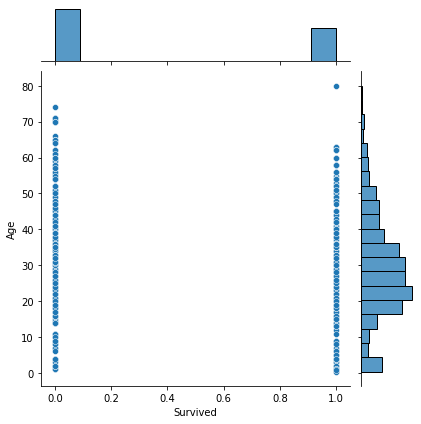

In [22]:
plt.figure(figsize=(6,6))
sns.jointplot(x='Survived', y='Age', data=train)
plt.show()

<Figure size 432x432 with 0 Axes>

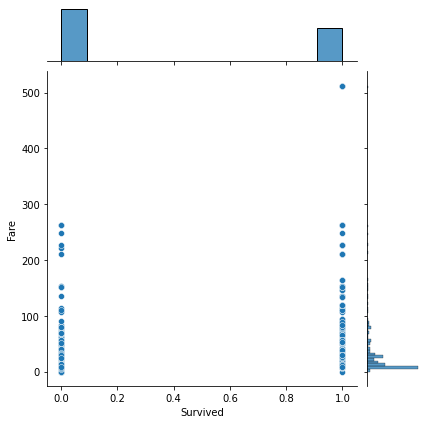

In [23]:
plt.figure(figsize=(6,6))
sns.jointplot(x='Survived', y='Fare', data=train)
plt.show()

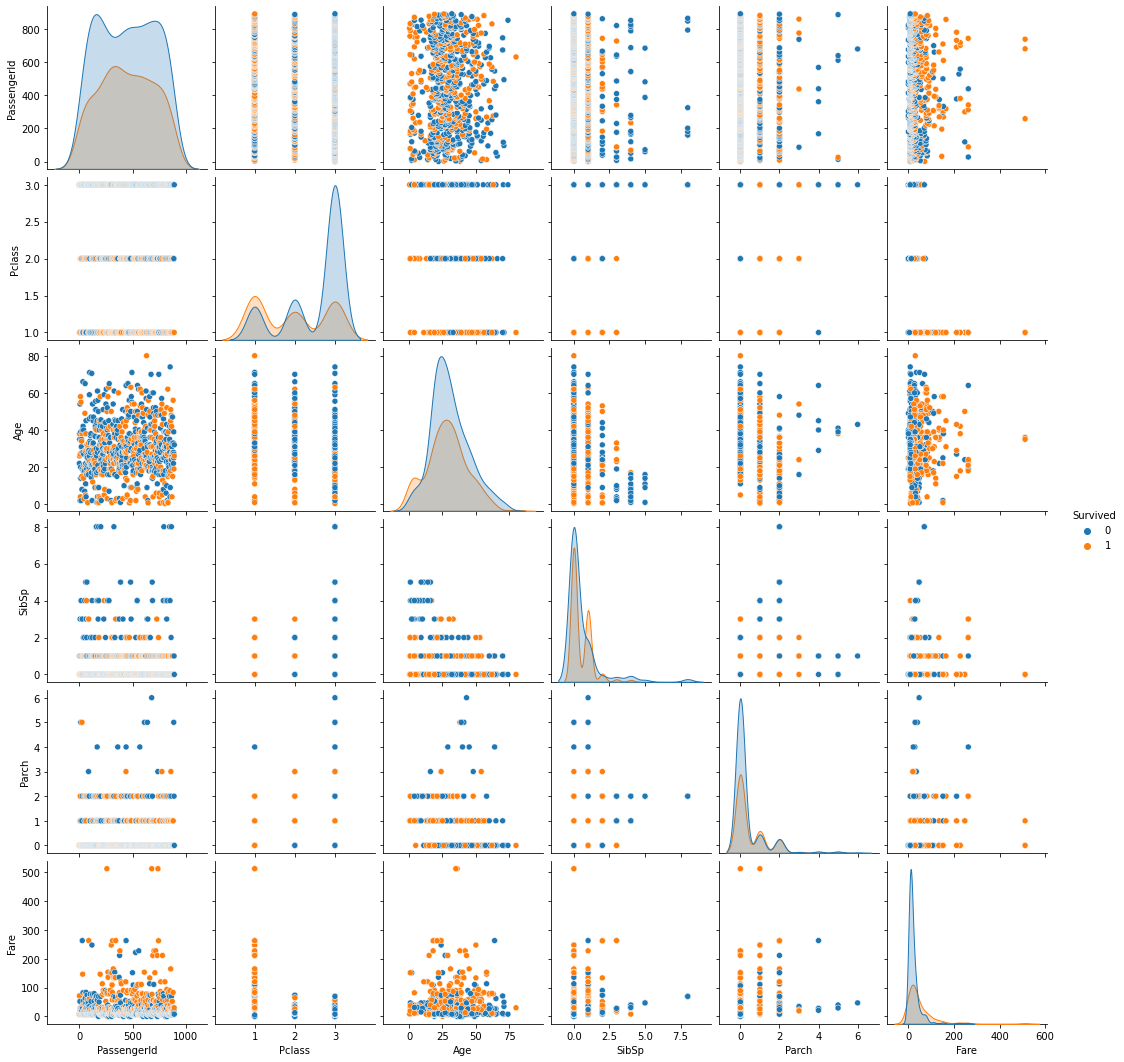

In [24]:
sns.pairplot(data=train, hue='Survived')
plt.show()

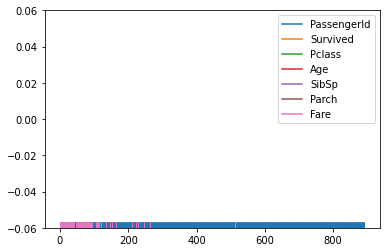

In [25]:
sns.rugplot(data=train)
plt.show()

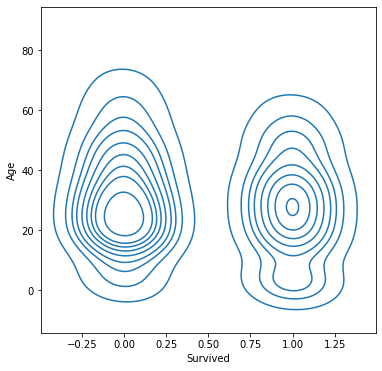

In [26]:
plt.figure(figsize=(6,6))
sns.kdeplot(x='Survived', y='Age', data=train)
plt.show()

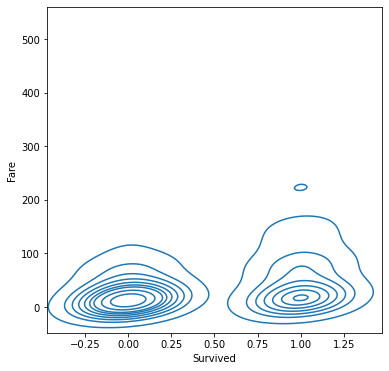

In [27]:
plt.figure(figsize=(6,6))
sns.kdeplot(x='Survived', y='Fare', data=train)
plt.show()

Analyse target

<AxesSubplot:xlabel='Survived', ylabel='Count'>

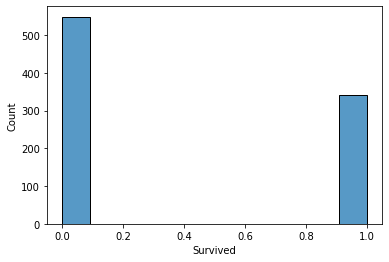

In [28]:
sns.histplot(train['Survived'])

In [29]:
tot_survived = train.groupby('Survived')['Survived'].count()
tot_survived

Survived
0    549
1    342
Name: Survived, dtype: int64

In [30]:
tot_survived_percent = tot_survived / len(train)
tot_survived_percent

Survived
0    0.616162
1    0.383838
Name: Survived, dtype: float64

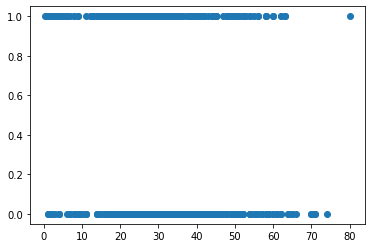

In [31]:
plt.scatter(train['Age'], train['Survived'])

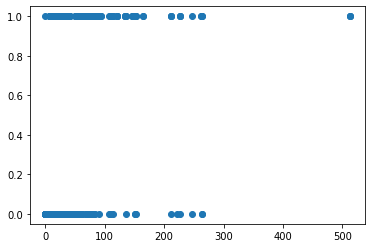

In [32]:
plt.scatter(train['Fare'], train['Survived'])

In [33]:
ra = np.corrcoef(train['Age'], train['Survived'])
ra

array([[nan, nan],
       [nan,  1.]])

In [34]:
rf = np.corrcoef(train['Fare'], train['Survived'])
rf

array([[1.        , 0.25730652],
       [0.25730652, 1.        ]])

<AxesSubplot:xlabel='Age', ylabel='Survived'>

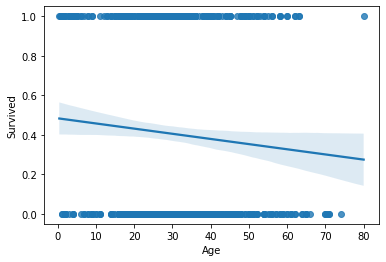

In [35]:
sns.regplot(x='Age', y='Survived', data=train)

<AxesSubplot:xlabel='Fare', ylabel='Survived'>

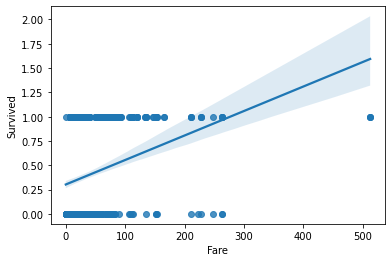

In [36]:
sns.regplot(x='Fare', y='Survived', data=train)

<function matplotlib.pyplot.show(close=None, block=None)>

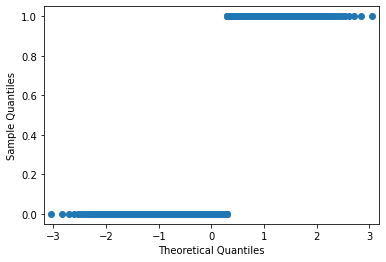

In [37]:
sm.qqplot(train['Survived'])
plt.show

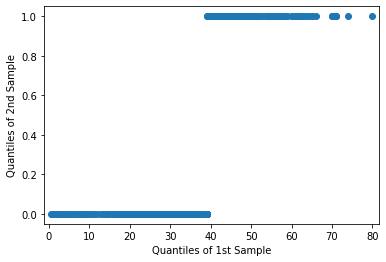

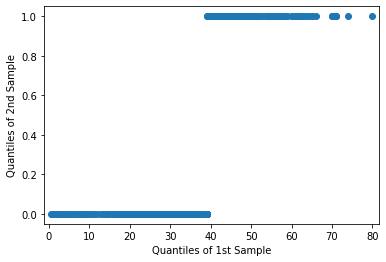

In [38]:
sm.qqplot_2samples(train['Age'], train['Survived'])

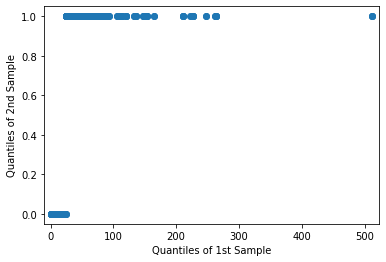

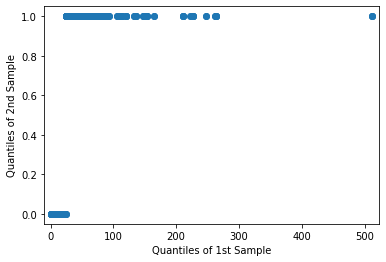

In [39]:
sm.qqplot_2samples(train['Fare'], train['Survived'])

<AxesSubplot:xlabel='Age', ylabel='Survived'>

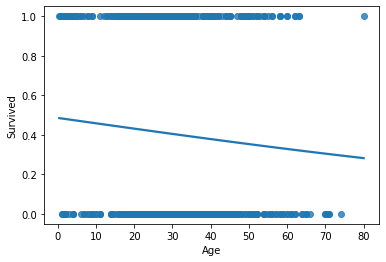

In [40]:
sns.regplot(x=train['Age'], y=train['Survived'], logistic=True,ci=None)

Define target

In [41]:
target = train['Survived']

Drop survived from train

In [42]:
train.drop('Survived', axis=1, inplace=True)
train

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Combine train and test

In [43]:
combi = train.append(test)
combi

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


Drop id

In [44]:
combi.drop(['PassengerId'], axis=1, inplace=True)
combi

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


Create titles

In [45]:
combi['Title'] = combi['Name'].map(lambda name:name.split(',')[1].split('.')[0].strip())
combi

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Dona
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Mr


In [46]:
combi['Title'].replace({    
    "Capt": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Jonkheer": "Royalty",
    "Don": "Royalty",
    "Sir" : "Royalty",
    "Dr": "Officer",
    "Rev": "Officer",
    "the Countess":"Royalty",
    "Mme": "Mrs",
    "Mlle": "Miss",
    "Ms": "Mrs",
    "Mr" : "Mr",
    "Mrs" : "Mrs",
    "Miss" : "Miss",
    "Master" : "Master",
    "Lady" : "Royalty",
    "Dona": "Royalty"
},inplace=True)
combi

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,Mr
414,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,Royalty
415,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr
416,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,Mr


Check for null values

In [47]:
combi.isnull().sum()

Pclass         0
Name           0
Sex            0
Age          263
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin       1014
Embarked       2
Title          0
dtype: int64

Replace null values

In [48]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(random_state=42)

date = pd.Timestamp('2200-01-01')

for col in combi:
    if combi[col].dtype=="object":
        combi[col].fillna("not listed", inplace=True)
    if combi[col].dtype=="int":
        #X[col].fillna(X[col].mode()[0], inplace=True)
        combi[col].fillna(combi[col].mean(), inplace=True)
        #combi[col] = combi[col].astype.int()
    if combi[col].dtype=='float':
       #X[col].fillna(X[col].mean(), inplace=True)
       combi[col] = imp.fit_transform(combi[col].values.reshape(-1,1))
    if combi[col].dtype=="datetime64[ns]":
        combi[col].fillna(date, inplace=True)
combi


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,not listed,S,Mr
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,not listed,S,Miss
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,Mrs
4,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,not listed,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,29.881138,0,0,A.5. 3236,8.0500,not listed,S,Mr
414,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,Royalty
415,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,not listed,S,Mr
416,3,"Ware, Mr. Frederick",male,29.881138,0,0,359309,8.0500,not listed,S,Mr


In [49]:
combi.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
Title       0
dtype: int64

Heatmap

<AxesSubplot:>

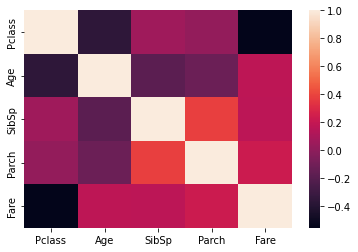

In [50]:
cmap = combi.corr()
sns.heatmap(cmap)

Bins

In [51]:
combi['Age_group'] = pd.cut(x=combi['Age'], bins=[0, 18, 40, 65, 100], labels=['child', 'young adult', 'middle age', 'pensioner'])
combi['Fare_group'] = pd.cut(x=combi['Fare'], bins=[0, 100, 400, 1000], labels=['low', 'middle', 'high'])
combi

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_group,Fare_group
0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,not listed,S,Mr,young adult,low
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,Mrs,young adult,low
2,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,not listed,S,Miss,young adult,low
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,Mrs,young adult,low
4,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,not listed,S,Mr,young adult,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,"Spector, Mr. Woolf",male,29.881138,0,0,A.5. 3236,8.0500,not listed,S,Mr,young adult,low
414,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,Royalty,young adult,middle
415,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,not listed,S,Mr,young adult,low
416,3,"Ware, Mr. Frederick",male,29.881138,0,0,359309,8.0500,not listed,S,Mr,young adult,low


In [52]:
combi['Age_group'] = combi['Age_group'].astype(str)
combi['Fare_group'] = combi['Fare_group'].astype(str)

Ordinal encode

In [53]:
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()

for col in combi:
    if combi[col].dtype=="O":
        combi[col] = enc.fit_transform(combi[col].values.reshape(-1,1))
combi

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_group,Fare_group
0,3,155.0,1.0,22.000000,1,0,720.0,7.2500,186.0,2.0,2.0,3.0,1.0
1,1,286.0,0.0,38.000000,1,0,816.0,71.2833,106.0,0.0,3.0,3.0,1.0
2,3,523.0,0.0,26.000000,0,0,914.0,7.9250,186.0,2.0,1.0,3.0,1.0
3,1,422.0,0.0,35.000000,1,0,65.0,53.1000,70.0,2.0,3.0,3.0,1.0
4,3,22.0,1.0,35.000000,0,0,649.0,8.0500,186.0,2.0,2.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,1126.0,1.0,29.881138,0,0,711.0,8.0500,186.0,2.0,2.0,3.0,1.0
414,1,891.0,0.0,39.000000,0,0,834.0,108.9000,64.0,0.0,5.0,3.0,2.0
415,3,1046.0,1.0,38.500000,0,0,872.0,7.2500,186.0,2.0,2.0,3.0,1.0
416,3,1227.0,1.0,29.881138,0,0,579.0,8.0500,186.0,2.0,2.0,3.0,1.0


In [54]:
combi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1309 entries, 0 to 417
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      1309 non-null   int64  
 1   Name        1309 non-null   float64
 2   Sex         1309 non-null   float64
 3   Age         1309 non-null   float64
 4   SibSp       1309 non-null   int64  
 5   Parch       1309 non-null   int64  
 6   Ticket      1309 non-null   float64
 7   Fare        1309 non-null   float64
 8   Cabin       1309 non-null   float64
 9   Embarked    1309 non-null   float64
 10  Title       1309 non-null   float64
 11  Age_group   1309 non-null   float64
 12  Fare_group  1309 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 143.2 KB


Standardise

In [55]:
combi = (combi - combi.mean()) / np.std(combi)
combi

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_group,Fare_group
0,0.841916,-1.319550,0.743497,-6.119717e-01,0.481288,-0.445000,0.922332,-0.503595,0.449010,0.618968,0.114370,0.6636,-0.254463
1,-1.546098,-0.972223,-1.344995,6.304311e-01,0.481288,-0.445000,1.267701,0.734503,-1.337885,-1.832558,1.361961,0.6636,-0.254463
2,0.841916,-0.343852,-1.344995,-3.013710e-01,-0.479087,-0.445000,1.620266,-0.490544,0.449010,0.618968,-1.133220,0.6636,-0.254463
3,-1.546098,-0.611639,-1.344995,3.974805e-01,0.481288,-0.445000,-1.434095,0.382925,-2.141988,0.618968,1.361961,0.6636,-0.254463
4,0.841916,-1.672180,0.743497,3.974805e-01,-0.479087,-0.445000,0.666902,-0.488127,0.449010,0.618968,0.114370,0.6636,-0.254463
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0.841916,1.254915,0.743497,2.206951e-15,-0.479087,-0.445000,0.889953,-0.488127,0.449010,0.618968,0.114370,0.6636,-0.254463
414,-1.546098,0.631847,-1.344995,7.080812e-01,-0.479087,-0.445000,1.332458,1.461829,-2.276005,-1.832558,3.857142,0.6636,2.773650
415,0.841916,1.042807,0.743497,6.692562e-01,-0.479087,-0.445000,1.469167,-0.503595,0.449010,0.618968,0.114370,0.6636,-0.254463
416,0.841916,1.522702,0.743497,2.206951e-15,-0.479087,-0.445000,0.415070,-0.488127,0.449010,0.618968,0.114370,0.6636,-0.254463


Define X and y

In [56]:
features = ['Pclass', 'Sex','Title',  'Age_group','Fare_group', 'Embarked']

y = target
X = combi[features][: len(train)]
X_test = combi[features][len(train) :]
X.shape, y.shape,X_test.shape

((891, 6), (891,), (418, 6))

Split dataset

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.10, random_state=1, stratify=y, shuffle=True)
X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape

((801, 6), (90, 6), (801,), (90,), (418, 6))

Select model

In [58]:
#extra tree classifier
from sklearn.tree import ExtraTreeClassifier

model = ExtraTreeClassifier(random_state=42).fit(X_train, y_train)
print(model.score(X_train, y_train))

0.8439450686641697


Predict on validation set

In [59]:
y_pred=model.predict(X_val)
print(model.score(X_val, y_val))

0.8111111111111111


In [60]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, y_pred))

[[52  3]
 [14 21]]


Predict on test set

In [61]:
predictions = model.predict(X_test)
predictions

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

Prepare submission

In [62]:
submission.Survived = predictions
submission.to_csv('submission.csv', index=False)
my_submission = pd.read_csv("submission.csv")
my_submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
